<a href="https://colab.research.google.com/github/JillFang1030/BrainHack_Final_Project/blob/main/Revised_Final_Project_BrainHack_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project

# Plotting



*   Make an interactive plot using plotly with my project data.
*   TD: typically developed; DD: dyslexia

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
## Exercise 4 (TD: typically developed; DD: dyslexia)
import pandas as pd
import plotly.express as px

# 1. load data
df_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
df_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

# 2. Label
df_dd['Group'] = 'DD'
df_td['Group'] = 'TD'

# 3. Merge
df_project = pd.concat([df_dd, df_td], ignore_index=True)

# 4. 印出所有欄位名稱
print("合併後的欄位有：\n", df_project.columns.tolist())

合併後的欄位有：
 ['ID', 'C_MC', 'C_CTOPP', 'C_RAN', 'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF', 'RF_inc_w/o skip', 'RF_inc_w/ skip', 'Character_recog (raw score)', 'Character_recog (PR)', "IQ_Raven's (raw)", "IQ_Raven's (Standard)", 'fNIRS_Date1', 'Chinese_MAPA', 'Story_Listening', 'Chinese_Priming', 'Chinese_semantic', 'Resting', 'Chinese_RAN', 'fNIRS_Date2', 'Chinese_MAPA.1', 'Story_Listening.1', 'Chinese_Priming.1', 'Chinese_semantic.1', 'Resting.1', 'Chinese_RAN.1', 'Group', 'C_PIC(52)', 'RF_inc_w/o_skip', 'RF_inc_w/_skip', 'Chinese_Semantic']


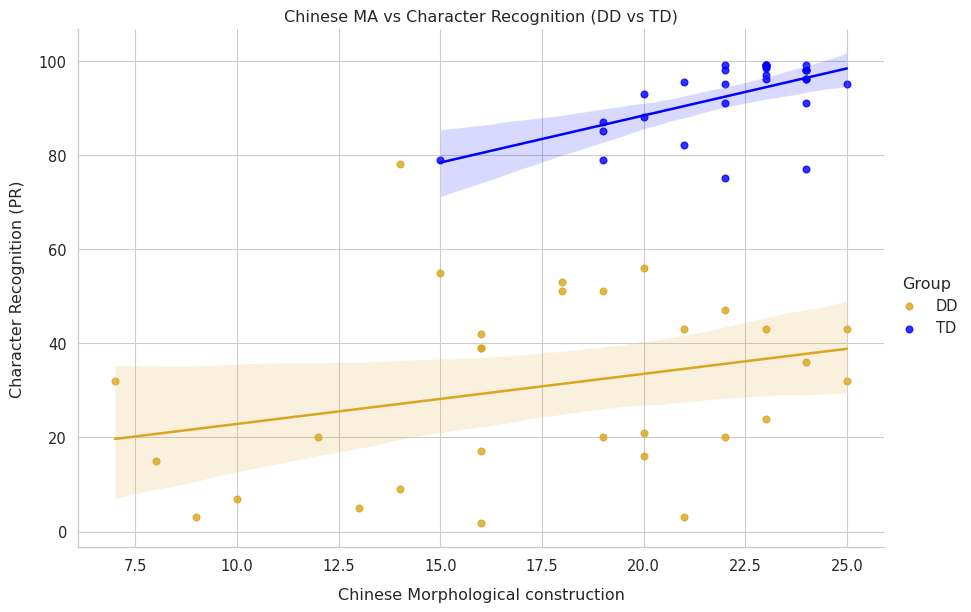

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定背景
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# 使用 lmplot 自動畫出散佈圖與趨勢線
sns.lmplot(
    data=df_project,
    x='C_MC',               # X軸：Chinese Morphological construction
    y='Character_recog (PR)',# Y軸：中文字認讀分數
    hue='Group',                    # 顏色：DD vs TD
    palette=['goldenrod', 'blue'],        # DD 用金色，TD 用藍色
    height=6,                       # 圖片高度
    aspect=1.5                      # 圖片長寬比
)

plt.xlabel('Chinese Morphological construction', labelpad=10)
plt.ylabel('Character Recognition (PR)', labelpad=10)

# 儲存圖片
# bbox_inches='tight' 可以確保圖片邊緣的字不會被意外切掉
plt.savefig('my_research_plot.png', dpi=300, bbox_inches='tight')

plt.title('Chinese MA vs Character Recognition (DD vs TD)')
plt.show()

# 畫完重置設定
sns.reset_orig()

In [30]:
import plotly.express as px

# 用 Plotly 畫出 MA 與認字分數的關係，並加上趨勢線
fig = px.scatter(
    df_project,
    x='C_MC',
    y='Character_recog (PR)',
    color='Group',
    trendline="ols",                # Plotly 也能畫趨勢線 (OLS 迴歸線)
    hover_data=['ID'], # 游標移上去可以看到學生 ID
    labels={'C_MC': 'Chinese MA (C_MC)', 'Character_recog (raw score)': 'Character Recognition (Raw)'},
    title='Interactive Chinese MA vs Character Recognition (DD vs TD)',
    template='plotly_white',        # 乾淨的白色背景
    color_discrete_map={'DD': 'goldenrod', 'TD': 'blue'}
)

fig.show()
fig.write_html("my_interactive_plot.html")

# Correlation





In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# 設定資料夾路徑
folder_path = '/content/drive/MyDrive/Colab Notebooks/'

# --- 1. 直接指定你目前的檔案名稱 ---
try:
    # 讀取 Beta 資料 (CSV 格式)
    df_beta_dd = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_DD.csv')
    df_beta_td = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_TD.csv')

    # 讀取行為指標資料 (Excel 格式)
    df_behav_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
    df_behav_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

    print("✅ 所有檔案（CSV 與 Excel）讀取成功")
except Exception as e:
    print(f"❌ 讀取失敗：{e}")
    raise

✅ 所有檔案（CSV 與 Excel）讀取成功


In [33]:
# 2. 欄位標頭清洗 (清除隱形空格，防止抓不到 Character_recog (PR)) ---
for df in [df_beta_dd, df_beta_td, df_behav_dd, df_behav_td]:
    df.columns = df.columns.str.strip()

# 3. 處理 Beta 值 (提取 Channel 6, 16, 21 的 MA 條件)，合併兩組 Beta 資料
beta_all = pd.concat([df_beta_dd, df_beta_td], ignore_index=True)

# 篩選特定頻道與條件 (只選 cond 為 MA)
target_channels = [6, 16, 21]
beta_filtered = beta_all[(beta_all['Channel'].isin(target_channels)) & (beta_all['cond'] == 'MA')]

# 將長格式轉為寬格式：讓 Subject 變回 ID 欄位，Channel 數字變為標題
beta_pivot = beta_filtered.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
beta_pivot.columns = ['ID', 'Beta_CH6', 'Beta_CH16', 'Beta_CH21']

In [34]:
# --- 4. 合併行為指標 ---
# 合併兩組行為資料
behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)

# 提取 ID, C_MC 以及 Character_recog (PR)
# 注意：C_MC 在資料中代表 Morphological Construction
behavior_subset = behavior_all[['ID', 'C_MC', 'Character_recog (PR)']].copy()
# 要看完整行為指標名單做相關
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]

In [35]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.stats.multitest as smm


# 1. 撈取所有 9 個行為指標
# 合併兩組行為原始資料
behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)

# 已加入新加的所有指標
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]

# 提取 ID 以及所有我們要分析的行為指標
behavior_subset = behavior_all[['ID'] + target_behaviors].copy()

# 確保大腦表（beta_pivot）與行為表的 ID 型別一致（都轉成整數）
beta_pivot['ID'] = beta_pivot['ID'].astype(int)
behavior_subset['ID'] = behavior_subset['ID'].astype(int)

# 透過 ID 把大腦 Beta 資料與行為分數資料拼在一起（注意：大表不預先做整體 dropna）
final_df = pd.merge(beta_pivot, behavior_subset, on='ID', how='inner')



# 2. 定義全新相關分析引擎（個別 dropna 機制，外加 FDR 校正）
def run_correlation_with_fdr(df, channels, behaviors):
    results = []
    raw_p_values = [] # 用來存取所有的原始 p 值

    # 計算 3 個 Channel × 9 個指標 = 27 次 Pearson 相關
    for ch in channels:
        for bh in behaviors:
            if ch in df.columns and bh in df.columns:
                # 💡 【自動防錯核心】：只針對目前計算的這對指標個別去除缺失值，保留最多受試者
                valid_data = df[[ch, bh]].dropna()

                # 💡 【長度檢查】：確保人數夠才計算（長度大於 2），不夠就填空值，不讓程式死當
                if len(valid_data) > 2:
                    r_val, p_val = pearsonr(valid_data[ch], valid_data[bh])
                else:
                    r_val, p_val = np.nan, np.nan
            else:
                r_val, p_val = np.nan, np.nan

            results.append({
                'Channel': ch,
                'Behavior': bh,
                'Pearson_r': round(r_val, 3) if not np.isnan(r_val) else np.nan,
                'p_value_raw': round(p_val, 4) if not np.isnan(p_val) else np.nan
            })
            # 將 p 值存入清單。如果是 nan 則用 1.0 代替，確保校正不報錯
            raw_p_values.append(1.0 if np.isnan(p_val) else p_val)

    # 進行這 27 次比較的 FDR 多重比較校正
    reject, p_corrected, _, _ = smm.multipletests(raw_p_values, alpha=0.05, method='fdr_bh')

    # 將校正結果塞回表格
    for idx, res in enumerate(results):
        res['p_value_FDR_corrected'] = round(p_corrected[idx], 4)
        res['Significant_After_FDR'] = '★ TRUE' if reject[idx] else ''
        p_raw = res['p_value_raw']
        res['Significant_Raw'] = '*' if (p_raw is not None and p_raw < 0.05) else ''

    return pd.DataFrame(results)


# 3. 執行分析：計算整體的 27 行總表

target_channels_short = ['Beta_CH6', 'Beta_CH16', 'Beta_CH21']

# 3-1. 跑全體的相關分析
print("========== 全體兒童（N=30）27次相關分析結果 ==========")
analysis_results_all = run_correlation_with_fdr(final_df, target_channels_short, target_behaviors)
print(analysis_results_all.to_string(index=False))
analysis_results_all.to_excel('All_subjects_3ch_9behav_results.xlsx', index=False)

print("\n" + "="*80 + "\n")

========== 全體兒童（N=30）27次相關分析結果 ==========
  Channel             Behavior  Pearson_r  p_value_raw  p_value_FDR_corrected Significant_After_FDR Significant_Raw
 Beta_CH6                 C_MC      0.045       0.7345                 0.9711                                      
 Beta_CH6 Character_recog (PR)     -0.116       0.3764                 0.9711                                      
 Beta_CH6              C_CTOPP      0.017       0.8991                 0.9711                                      
 Beta_CH6                C_RAN     -0.004       0.9782                 0.9782                                      
 Beta_CH6                 C_CR     -0.108       0.4124                 0.9711                                      
 Beta_CH6                 C_WR     -0.040       0.7625                 0.9711                                      
 Beta_CH6                C_PIC     -0.085       0.5163                 0.9711                                      
 Beta_CH6           C_PIC (52)

In [36]:
# 導出：將全體兒童的 27 行相關分析結果存成 Excel 檔案
excel_filename = 'All_Subjects_60_Correlation_Results.xlsx'

analysis_results_all.to_excel(excel_filename, index=False)

print("\n" + "="*60)
print(f"🎉 全體兒童 Excel 表格已成功導出！")
print(f"📁 檔案名稱：{excel_filename}")
print("💡 說明：請點開 Colab 左側的小資料夾，就能直接下載囉！")
print("="*60)


🎉 全體兒童 Excel 表格已成功導出！
📁 檔案名稱：All_Subjects_60_Correlation_Results.xlsx
💡 說明：請點開 Colab 左側的小資料夾，就能直接下載囉！


只有CH16的C_PIC (52)有超級微小的顯著

✅ 檔案重讀成功！大資料庫就位。
⏳ 正在計算目標 3通道 ✕ 9指標 的 27 次相關矩陣...
🎉 【目標 3 通道熱圖已成功存檔】：target_3ch_9behav_heatmap.png


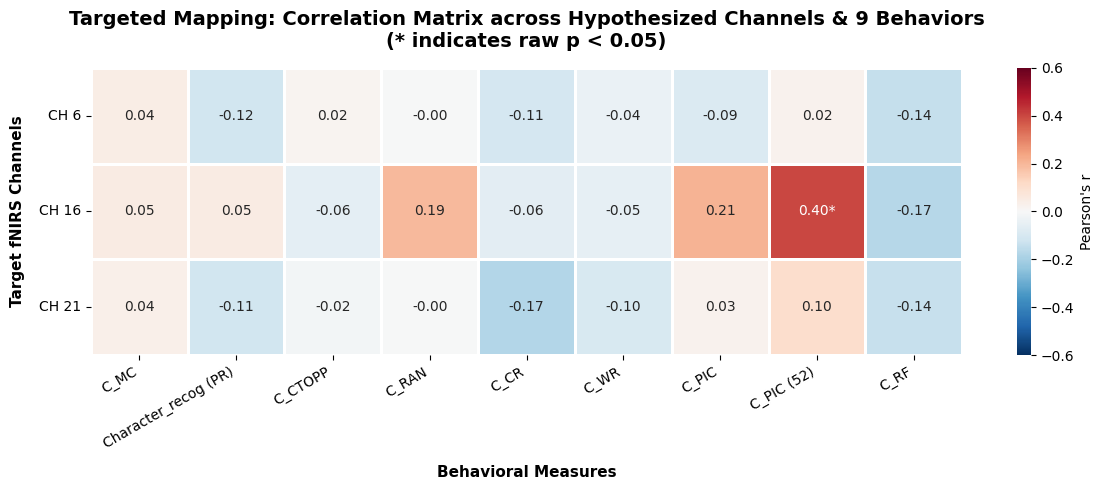

🎉 【27行原始統計總表已自動存檔】：All_Subjects_60_Correlation_Results.xlsx


In [37]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================================
# 1. 讀取檔案與建立大資料庫 (確保硬碟已掛載)
# =====================================================================
try:
    df_beta_dd = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_DD.csv')
    df_beta_td = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_TD.csv')
    df_behav_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
    df_behav_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

    for df in [df_beta_dd, df_beta_td, df_behav_dd, df_behav_td]:
        df.columns = df.columns.str.strip()

    beta_all = pd.concat([df_beta_dd, df_beta_td], ignore_index=True)
    behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)
    print("✅ 檔案重讀成功！大資料庫就位。")
except Exception as e:
    print(f"❌ 檔案讀取失敗，請確認雲端硬碟路徑：{e}")
    raise

# =====================================================================
# 2. 🚀 【核心修正】只鎖定黃金 3 個 Channel (CH6, CH16, CH21)
# =====================================================================
target_channels = [6, 16, 21]  # 👈 這裡直接砍掉全腦，只留這三個！

beta_ma_all = beta_all[beta_all['cond'] == 'MA'].copy()
beta_pivot_3ch = beta_ma_all.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
beta_pivot_3ch.rename(columns={'Subject': 'ID'}, inplace=True)
beta_pivot_3ch['ID'] = beta_pivot_3ch['ID'].astype(int)

# 9 個行為指標名單
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]
behavior_subset = behavior_all[['ID'] + target_behaviors].copy()
behavior_subset['ID'] = behavior_subset['ID'].astype(int)

# 合併成 3通道 專屬大表
final_df_3ch = pd.merge(beta_pivot_3ch, behavior_subset, on='ID', how='inner')

# =====================================================================
# 3. 計算 3 通道 ✕ 9 指標 = 27 次相關
# =====================================================================
print("⏳ 正在計算目標 3通道 ✕ 9指標 的 27 次相關矩陣...")

matrix_r = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)
matrix_annot = pd.DataFrame(index=[f'CH {ch}' for ch in target_channels], columns=target_behaviors)
results_list_27 = []

for ch in target_channels:
    for bh in target_behaviors:
        if ch in final_df_3ch.columns and bh in final_df_3ch.columns:
            valid_data = final_df_3ch[[ch, bh]].dropna()
            if len(valid_data) > 2:
                r_val, p_val = pearsonr(valid_data[ch], valid_data[bh])
            else:
                r_val, p_val = np.nan, np.nan
        else:
            r_val, p_val = np.nan, np.nan

        matrix_r.loc[f'CH {ch}', bh] = r_val if not np.isnan(r_val) else 0.0

        # 如果原始 p 值 < 0.05，標註星號
        if not np.isnan(p_val) and p_val < 0.05:
            matrix_annot.loc[f'CH {ch}', bh] = f"{r_val:.2f}*"
        else:
            matrix_annot.loc[f'CH {ch}', bh] = f"{r_val:.2f}" # 沒顯著也顯示 r 值，讓圖表資訊更豐富

        results_list_27.append({
            'Channel': f'CH {ch}',
            'Behavior': bh,
            'Pearson_r': round(r_val, 3) if not np.isnan(r_val) else np.nan,
            'p_value_raw': round(p_val, 4) if not np.isnan(p_val) else np.nan
        })

# =====================================================================
# 4. 🎨 繪製精緻的 3✕9 核心熱圖 (調整為扁平好放進 PPT 的完美比例)
# =====================================================================
plt.figure(figsize=(12, 5)) # 👈 寬 12 高 5，完美的黃金比例扁平圖！
matrix_r = matrix_r.astype(float)

sns.heatmap(matrix_r,
            annot=matrix_annot.values,
            fmt="",
            cmap='RdBu_r',
            vmin=-0.6, vmax=0.6,
            center=0.0,
            linewidths=1.0,
            cbar_kws={'label': "Pearson's r"})

plt.title('Targeted Mapping: Correlation Matrix across Hypothesized Channels & 9 Behaviors\n(* indicates raw p < 0.05)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Behavioral Measures', fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel('Target fNIRS Channels', fontsize=11, fontweight='bold', labelpad=10)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# 💾 【精準對齊新故事線：存檔新檔名】
plt.savefig('target_3ch_9behav_heatmap.png', dpi=300, bbox_inches='tight')
print("🎉 【目標 3 通道熱圖已成功存檔】：target_3ch_9behav_heatmap.png")

plt.show()

# =====================================================================
# 5. 儲存 27 行總表成 Excel
# =====================================================================
df_results_27 = pd.DataFrame(results_list_27)
df_results_27.to_excel('All_Subjects_60_Correlation_Results.xlsx', index=False)
print("🎉 【27行原始統計總表已自動存檔】：All_Subjects_60_Correlation_Results.xlsx")